In [2]:
# ============================================================
# SECTION 0: Imports & Data Load
# ============================================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.stats.stattools import durbin_watson

data = pd.read_csv("/content/Exam_Score_Prediction.csv")
print(data.shape)
data.head()

(20000, 13)


,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [3]:
# ============================================================
# SECTION 1: Basic EDA
# ============================================================
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


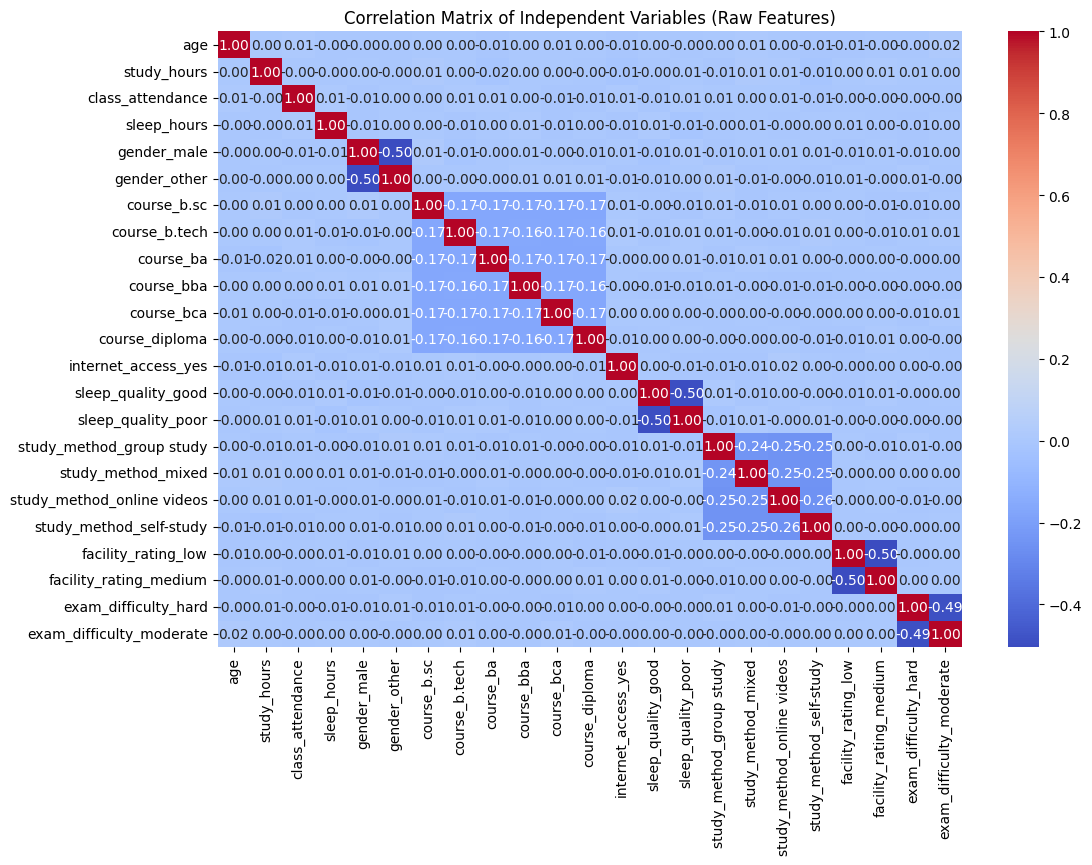

                       feature       VIF
11                  course_bca  1.722205
9                    course_ba  1.720921
7                  course_b.sc  1.718045
10                  course_bba  1.709301
12              course_diploma  1.707037
8                course_b.tech  1.702327
19     study_method_self-study  1.601815
18  study_method_online videos  1.600724
16    study_method_group study  1.586046
17          study_method_mixed  1.583229
5                  gender_male  1.344261
6                 gender_other  1.343892
21      facility_rating_medium  1.340781
20         facility_rating_low  1.340484
14          sleep_quality_good  1.331591
15          sleep_quality_poor  1.331567
23    exam_difficulty_moderate  1.321322
22        exam_difficulty_hard  1.321097
2                  study_hours  1.001245
13         internet_access_yes  1.001127
4                  sleep_hours  1.000901
1                          age  1.000824
3             class_attendance  1.000803


In [4]:
# ============================================================
# SECTION 2: Multicollinearity Check (VIF) — RAW FEATURES
# (same logic as your original Cell 6, run on raw features)
# ============================================================
features = data.drop(columns=['student_id', 'exam_score'])
features_encoded = pd.get_dummies(features, drop_first=True)

plt.figure(figsize=(12, 8))
correlation_matrix = features_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Independent Variables (Raw Features)")
plt.show()

X_vif = add_constant(features_encoded.astype(float))
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
vif_results = vif_data[vif_data['feature'] != 'const'].sort_values(by="VIF", ascending=False)
print(vif_results)

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.732
Model:                            OLS   Adj. R-squared:                  0.732
Method:                 Least Squares   F-statistic:                     2375.
Date:                Sun, 09 Aug 2026   Prob (F-statistic):               0.00
Time:                        11:40:24   Log-Likelihood:                -73994.
No. Observations:               20000   AIC:                         1.480e+05
Df Residuals:                   19976   BIC:                         1.482e+05
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

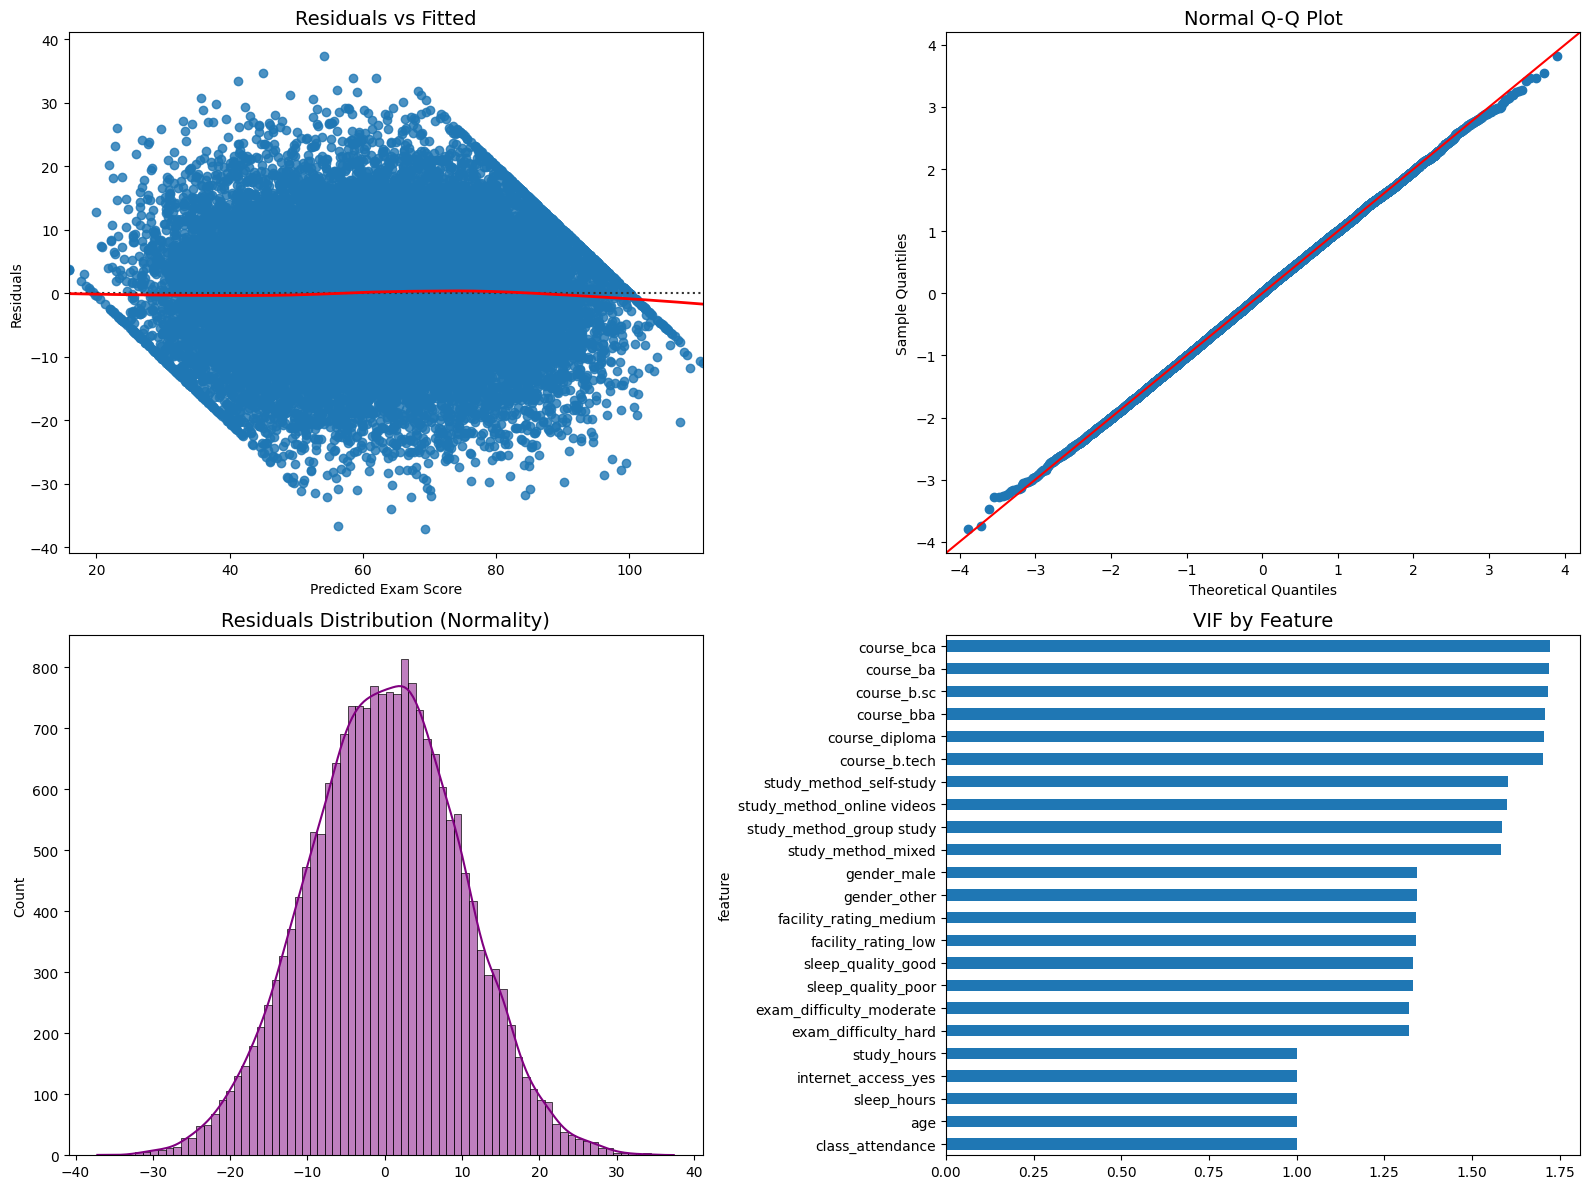


Durbin-Watson Score: 2.0170
Note: Values closer to 2.0 indicate no autocorrelation (independence).


In [5]:
# ============================================================
# SECTION 3: OLS Fit + Assumption Diagnostics — RAW FEATURES
# ============================================================
X_ols = features_encoded.replace([np.inf, -np.inf], np.nan)
X_ols = X_ols.fillna(X_ols.median())
X_ols = X_ols.astype(float)

X_ols_const = sm.add_constant(X_ols)
y_ols = data['exam_score']

if X_ols_const.isnull().values.any():
    X_ols_const = X_ols_const.dropna()
    y_ols = y_ols[X_ols_const.index]

ols_model = sm.OLS(y_ols, X_ols_const).fit()
print(ols_model.summary())

residuals = ols_model.resid
fitted_vals = ols_model.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.residplot(x=fitted_vals, y=residuals, lowess=True, ax=axes[0, 0],
              line_kws={'color': 'red', 'lw': 2})
axes[0, 0].set_title('Residuals vs Fitted', fontsize=14)
axes[0, 0].set_xlabel('Predicted Exam Score')
axes[0, 0].set_ylabel('Residuals')

sm.qqplot(residuals, line='45', fit=True, ax=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q Plot', fontsize=14)

sns.histplot(residuals, kde=True, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Residuals Distribution (Normality)', fontsize=14)

vif_plot = vif_results.sort_values(by="VIF")
vif_plot.plot(kind='barh', x='feature', y='VIF', ax=axes[1, 1], legend=False)
axes[1, 1].set_title('VIF by Feature', fontsize=14)

plt.tight_layout()
plt.show()

dw_score = durbin_watson(residuals)
print(f"\nDurbin-Watson Score: {dw_score:.4f}")
print("Note: Values closer to 2.0 indicate no autocorrelation (independence).")

In [6]:
# ============================================================
# SECTION 4: Train/Test Split + Preprocessing Pipeline (Raw Features)
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = data.drop(columns=['student_id', 'exam_score'])
y = data['exam_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numerical_cols = ['age', 'study_hours', 'class_attendance', 'sleep_hours']
categorical_cols = ['gender', 'course', 'internet_access', 'sleep_quality',
                     'study_method', 'facility_rating', 'exam_difficulty']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
])

X_train_proc = preprocessor.fit_transform(X_train).astype('float32')
X_test_proc  = preprocessor.transform(X_test).astype('float32')
input_dim = X_train_proc.shape[1]
print(f"Input dim after preprocessing: {input_dim}")

Input dim after preprocessing: 23


In [7]:
# ============================================================
# SECTION 5: Baseline Models — Linear, Ridge, Lasso, XGBoost
# ============================================================
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

baseline_results = {}

models = {
    "Linear Regression": LinearRegression(),
    "Ridge (L2)": RidgeCV(alphas=np.logspace(-6, 6, 13)),
    "Lasso (L1)": LassoCV(cv=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6,
                             subsample=0.8, colsample_bytree=0.8,
                             n_jobs=-1, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_proc, y_train)
    preds = model.predict(X_test_proc)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    baseline_results[name] = {"R2": r2, "RMSE": rmse}
    print(f"{name}: R2={r2:.4f}, RMSE={rmse:.4f}")

baseline_df = pd.DataFrame(baseline_results).T.sort_values(by='R2', ascending=False)
print("\n", baseline_df)

# Keep the fitted Ridge model — it's our Stage 1 model going forward
ridge_final = models["Ridge (L2)"]

Linear Regression: R2=0.7330, RMSE=9.7725
Ridge (L2): R2=0.7330, RMSE=9.7725
Lasso (L1): R2=0.7332, RMSE=9.7693
XGBoost: R2=0.7055, RMSE=10.2632

                          R2       RMSE
Lasso (L1)         0.733185   9.769276
Ridge (L2)         0.733011   9.772476
Linear Regression  0.733008   9.772517
XGBoost            0.705522  10.263239


In [8]:
# ============================================================
# SECTION 6: ANN Attempt #1 — Plain MLP (heavy regularization)
# WHY: Test if an ANN can even match Ridge before adding complexity
# ============================================================
import tensorflow as tf
from tensorflow.keras import layers, regularizers, callbacks

def build_baseline_mlp(input_dim):
    model = tf.keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.2),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

mlp_v1 = build_baseline_mlp(input_dim)
es_v1 = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history_v1 = mlp_v1.fit(X_train_proc, y_train, validation_split=0.15,
                         epochs=200, batch_size=128, callbacks=[es_v1], verbose=1)

pred_v1 = mlp_v1.predict(X_test_proc).flatten()
r2_v1 = r2_score(y_test, pred_v1)
print(f"Plain MLP v1 (heavy reg) R2: {r2_v1:.4f}")
# RESULT: Underperformed Ridge. Train loss > val loss (dropout noise inflating
# train loss on a mostly-linear target) => regularization suspected as bottleneck.

Epoch 1/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 3182.0115 - mae: 52.3043 - val_loss: 921.3959 - val_mae: 25.8898
Epoch 2/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 431.7414 - mae: 16.6225 - val_loss: 262.1824 - val_mae: 12.9398
Epoch 3/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 322.0663 - mae: 14.3560 - val_loss: 230.9695 - val_mae: 12.1504
Epoch 4/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 293.8751 - mae: 13.6997 - val_loss: 208.9597 - val_mae: 11.5939
Epoch 5/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 275.5021 - mae: 13.2011 - val_loss: 191.9256 - val_mae: 11.1014
Epoch 6/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 254.3007 - mae: 12.7551 - val_loss: 174.8022 - val_mae: 10.6064
Epoch 7/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 243.2566 - mae: 12.4875 - val_loss: 163.1040 - val_mae: 10.2335
Epoch 8/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 224.1419 - mae: 12.0119 - val_loss: 150.7623 - val_mae: 9.8592

In [9]:
# ============================================================
# SECTION 7: ANN Attempt #2 — Plain MLP (loosened regularization)
# WHY: Test if lighter dropout/no L2 closes the gap to Ridge
# ============================================================
def build_baseline_mlp_v2(input_dim):
    model = tf.keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

mlp_v2 = build_baseline_mlp_v2(input_dim)
es_v2 = callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
history_v2 = mlp_v2.fit(X_train_proc, y_train, validation_split=0.15,
                         epochs=300, batch_size=128, callbacks=[es_v2], verbose=1)

pred_v2 = mlp_v2.predict(X_test_proc).flatten()
r2_v2 = r2_score(y_test, pred_v2)
print(f"Plain MLP v2 (light reg) R2: {r2_v2:.4f}")
# RESULT: Improved, train/val loss inversion resolved, but still short of Ridge.
# => Regularization wasn't the full story. Architecture itself suspected next.

Epoch 1/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 3356.1995 - mae: 54.0981 - val_loss: 1215.3792 - val_mae: 30.4619
Epoch 2/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 436.8590 - mae: 16.6252 - val_loss: 265.2303 - val_mae: 13.0683
Epoch 3/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 280.4110 - mae: 13.4044 - val_loss: 232.6964 - val_mae: 12.2509
Epoch 4/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 256.7755 - mae: 12.8251 - val_loss: 206.8640 - val_mae: 11.5528
Epoch 5/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 231.1657 - mae: 12.1299 - val_loss: 186.3856 - val_mae: 10.9671
Epoch 6/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 209.8469 - mae: 11.5691 - val_loss: 169.2803 - val_mae: 10.4605
Epoch 7/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 190.7271 - mae: 11.0157 - val_loss: 156.0548 - val_mae: 10.0511
Epoch 8/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 183.4104 - mae: 10.8457 - val_loss: 144.9308 - val_mae: 9.700

In [10]:
# ============================================================
# SECTION 8: ANN Attempt #3 — Wide & Deep (JOINT training)
# WHY: Give the model an explicit linear branch (guarantees Ridge-level fit)
#      + a deep branch that only needs to learn residual non-linearity
# ============================================================
from tensorflow.keras import Model

def build_wide_deep(input_dim):
    inputs = layers.Input(shape=(input_dim,), name='inputs')
    wide_output = layers.Dense(1, activation='linear',
                                kernel_regularizer=regularizers.l2(1e-3),
                                name='wide_output')(inputs)
    x = layers.Dense(64, activation='relu')(inputs)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    deep_output = layers.Dense(1, activation='linear', name='deep_output')(x)
    combined = layers.Add()([wide_output, deep_output])
    model = Model(inputs=inputs, outputs=combined, name='wide_deep')
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

wide_deep_v1 = build_wide_deep(input_dim)
es_wd1 = callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
history_wd1 = wide_deep_v1.fit(X_train_proc, y_train, validation_split=0.15,
                                epochs=300, batch_size=128, callbacks=[es_wd1], verbose=1)

pred_wd1 = wide_deep_v1.predict(X_test_proc).flatten()
r2_wd1 = r2_score(y_test, pred_wd1)
print(f"Wide & Deep (joint, L2 wide branch) R2: {r2_wd1:.4f}")
# RESULT: No improvement over plain MLP v2. Wide branch wasn't functioning
# as a clean linear fit inside joint training => test if L2 was too strong.

Epoch 1/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 3360.9958 - mae: 54.3683 - val_loss: 1319.4351 - val_mae: 32.2001
Epoch 2/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 453.1496 - mae: 16.8770 - val_loss: 264.7704 - val_mae: 13.0318
Epoch 3/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 288.1281 - mae: 13.5671 - val_loss: 230.7165 - val_mae: 12.1905
Epoch 4/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 252.8435 - mae: 12.7160 - val_loss: 203.3620 - val_mae: 11.4706
Epoch 5/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 227.9899 - mae: 12.0503 - val_loss: 181.5052 - val_mae: 10.8237
Epoch 6/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 202.2575 - mae: 11.3984 - val_loss: 164.7669 - val_mae: 10.2982
Epoch 7/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 187.1499 - mae: 10.9115 - val_loss: 150.1168 - val_mae: 9.8405
Epoch 8/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 173.3400 - mae: 10.5201 - val_loss: 139.3089 - val_mae: 9.4710

In [11]:
# ============================================================
# SECTION 9: ANN Attempt #4 — Wide & Deep (tuned: no L2, lower LR)
# WHY: Isolate whether wide-branch L2 or joint-training gradient
#      competition was suppressing the linear branch's fit
# ============================================================
def build_wide_deep_v2(input_dim):
    inputs = layers.Input(shape=(input_dim,), name='inputs')
    wide_output = layers.Dense(1, activation='linear', name='wide_output')(inputs)
    x = layers.Dense(64, activation='relu')(inputs)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.1)(x)
    deep_output = layers.Dense(1, activation='linear', name='deep_output')(x)
    combined = layers.Add()([wide_output, deep_output])
    model = Model(inputs=inputs, outputs=combined, name='wide_deep_v2')
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
                  loss='mse', metrics=['mae'])
    return model

wide_deep_v2 = build_wide_deep_v2(input_dim)
es_wd2 = callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
history_wd2 = wide_deep_v2.fit(X_train_proc, y_train, validation_split=0.15,
                                epochs=400, batch_size=128, callbacks=[es_wd2], verbose=1)

pred_wd2 = wide_deep_v2.predict(X_test_proc).flatten()
r2_wd2 = r2_score(y_test, pred_wd2)
print(f"Wide & Deep (tuned) R2: {r2_wd2:.4f}")
# RESULT: Still no real gain. Rules out L2 as main cause. Points to
# joint-training gradient imbalance: deep branch (~3500 params) dominates
# updates over wide branch (~23 params) regardless of L2/LR tuning.
# => Solution: stop training them jointly. Stage them instead.

Epoch 1/400
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 3933.7812 - mae: 59.8695 - val_loss: 3309.8975 - val_mae: 54.3747
Epoch 2/400
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1999.1416 - mae: 39.6877 - val_loss: 612.4646 - val_mae: 20.3028
Epoch 3/400
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 389.5999 - mae: 15.7931 - val_loss: 290.3662 - val_mae: 13.6417
Epoch 4/400
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 304.8954 - mae: 13.9242 - val_loss: 258.4800 - val_mae: 12.8807
Epoch 5/400
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 280.1436 - mae: 13.4175 - val_loss: 239.0081 - val_mae: 12.4095
Epoch 6/400
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 264.9670 - mae: 13.0257 - val_loss: 223.4728 - val_mae: 12.0186
Epoch 7/400
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 247.7745 - mae: 12.5668 - val_loss: 209.7281 - val_mae: 11.6448
Epoch 8/400
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 234.7546 - mae: 12.2443 - val_loss: 197.6631 - val_mae: 11.3

In [12]:
# ============================================================
# SECTION 10: ANN Attempt #5 — STAGED Wide + Deep (the fix)
# WHY: Fit the linear part FULLY and IN ISOLATION first (pure Ridge,
#      no ANN interference). Then train the MLP ONLY on the residuals
#      Ridge couldn't explain. This makes it structurally impossible
#      for the deep branch to dominate the linear branch's gradients,
#      because the linear branch is already finished training.
# ============================================================
def build_residual_mlp(input_dim):
    model = tf.keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Stage 1: Ridge (reusing ridge_final fitted in Section 5)
train_pred_linear = ridge_final.predict(X_train_proc)
test_pred_linear  = ridge_final.predict(X_test_proc)
print(f"Stage 1 (Ridge alone) R2: {r2_score(y_test, test_pred_linear):.4f}")

train_residuals = y_train - train_pred_linear

# Stage 2: MLP trained only on residuals
residual_model = build_residual_mlp(input_dim)
es_res = callbacks.EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
history_res = residual_model.fit(X_train_proc, train_residuals, validation_split=0.15,
                                  epochs=300, batch_size=128, callbacks=[es_res], verbose=1)

predicted_residuals = residual_model.predict(X_test_proc).flatten()
y_pred_staged = test_pred_linear + predicted_residuals

r2_staged = r2_score(y_test, y_pred_staged)
rmse_staged = np.sqrt(mean_squared_error(y_test, y_pred_staged))
print(f"Staged Wide+Deep (RAW features) R2: {r2_staged:.4f}, RMSE: {rmse_staged:.4f}")
print(f"Improvement over Ridge: {r2_staged - r2_score(y_test, test_pred_linear):.4f}")
# RESULT: R2 essentially matches Ridge exactly (~0.733 both). Validation loss
# on the residual model increases from epoch 1 => no learnable signal left
# in the residuals. This is the clean, final answer: linear regression on
# raw features is at the ceiling; no genuine non-linear structure exists.

Stage 1 (Ridge alone) R2: 0.7330
Epoch 1/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 95.0707 - mae: 7.8095 - val_loss: 100.6805 - val_mae: 8.0973
Epoch 2/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 94.9342 - mae: 7.8044 - val_loss: 100.6977 - val_mae: 8.0991
Epoch 3/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 94.8651 - mae: 7.8036 - val_loss: 100.7156 - val_mae: 8.1015
Epoch 4/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 94.8107 - mae: 7.8003 - val_loss: 100.7725 - val_mae: 8.1028
Epoch 5/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 94.7450 - mae: 7.7969 - val_loss: 100.8756 - val_mae: 8.1076
Epoch 6/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 94.6339 - mae: 7.7931 - val_loss: 100.8733 - val_mae: 8.1102
Epoch 7/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 94.6029 - mae: 7.7907 - val_loss: 100.9426 - val_mae: 8.1133
Epoch 8/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 94.4843 - mae: 7.7884 - val_loss: 101.0532 - val_ma

In [13]:
# ============================================================
# SECTION 11: 5-Fold Cross-Validation (Confirms the Finding)
# WHY: Rule out the single train/test split being a lucky/unlucky draw
# ============================================================
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {'Ridge': {'r2': [], 'rmse': []},
              'XGBoost': {'r2': [], 'rmse': []},
              'Staged Wide+Deep': {'r2': [], 'rmse': []}}

fold_num = 1
for train_idx, test_idx in kf.split(X):
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

    pre_fold = ColumnTransformer(transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
    ])
    Xtr = pre_fold.fit_transform(X_train_fold).astype('float32')
    Xte = pre_fold.transform(X_test_fold).astype('float32')

    ridge_f = RidgeCV(alphas=np.logspace(-6, 6, 13)).fit(Xtr, y_train_fold)
    ridge_pred = ridge_f.predict(Xte)
    cv_results['Ridge']['r2'].append(r2_score(y_test_fold, ridge_pred))
    cv_results['Ridge']['rmse'].append(np.sqrt(mean_squared_error(y_test_fold, ridge_pred)))

    xgb_f = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6,
                          subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=42)
    xgb_f.fit(Xtr, y_train_fold)
    xgb_pred = xgb_f.predict(Xte)
    cv_results['XGBoost']['r2'].append(r2_score(y_test_fold, xgb_pred))
    cv_results['XGBoost']['rmse'].append(np.sqrt(mean_squared_error(y_test_fold, xgb_pred)))

    train_res_f = y_train_fold - ridge_f.predict(Xtr)
    res_model_f = build_residual_mlp(Xtr.shape[1])
    es_f = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    res_model_f.fit(Xtr, train_res_f, validation_split=0.15, epochs=200,
                     batch_size=128, callbacks=[es_f], verbose=0)
    staged_pred = ridge_pred + res_model_f.predict(Xte, verbose=0).flatten()
    cv_results['Staged Wide+Deep']['r2'].append(r2_score(y_test_fold, staged_pred))
    cv_results['Staged Wide+Deep']['rmse'].append(np.sqrt(mean_squared_error(y_test_fold, staged_pred)))

    print(f"Fold {fold_num}: Ridge={cv_results['Ridge']['r2'][-1]:.4f} | "
          f"XGBoost={cv_results['XGBoost']['r2'][-1]:.4f} | "
          f"Staged={cv_results['Staged Wide+Deep']['r2'][-1]:.4f}")
    fold_num += 1

print("\n5-FOLD CV SUMMARY")
for name, m in cv_results.items():
    print(f"{name}: R2={np.mean(m['r2']):.4f}±{np.std(m['r2']):.4f}, "
          f"RMSE={np.mean(m['rmse']):.2f}±{np.std(m['rmse']):.2f}")

Fold 1: Ridge=0.7330 | XGBoost=0.7043 | Staged=0.7325
Fold 2: Ridge=0.7389 | XGBoost=0.7102 | Staged=0.7391
Fold 3: Ridge=0.7261 | XGBoost=0.6994 | Staged=0.7263
Fold 4: Ridge=0.7271 | XGBoost=0.6949 | Staged=0.7272
Fold 5: Ridge=0.7322 | XGBoost=0.7038 | Staged=0.7324

5-FOLD CV SUMMARY
Ridge: R2=0.7315±0.0046, RMSE=9.80±0.05
XGBoost: R2=0.7025±0.0051, RMSE=10.31±0.06
Staged Wide+Deep: R2=0.7315±0.0046, RMSE=9.80±0.05
